# Utiliser la librairie Librosa

Librosa is a python package for music and audio analysis. 
It provides the building blocks necessary to create music information retrieval systems.

See [Librosa site](https://librosa.org/doc/latest/index.html).

## Préparation

Installez la libairie:
```
$ > pip install librosa
```
Puis importez les modules:

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython import display

from megamicros.log import log
import logging
from megamicros_aidb.query.db import AidbSession

log.setLevel( logging.DEBUG )

## Chargement des données audio

Téléchargez des signaux audio de la base de donné AiDB (voir les notebooks appropriés).
Ci-dessous nous travaillons sur le domaine 1 et téléchargeons 2 signaux dont le label est 15 (piglet-scream):

In [22]:
session = AidbSession( dbhost='http://dbwelfare.biimea.io/', login='ailab', email='bruno.gas@biimea.com', password='#T;uZnQ5UJ_JC~&' )
session.open()

audio = session.load_labelized( label_id=15, limit=2, channels=[1,7] )

2023-03-01 16:32:01,432 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-03-01 16:32:01,540 [INFO]:  .Logout successful.
2023-03-01 16:32:01,543 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-03-01 16:32:01,879 [INFO]:  .Got HTTP 200 status code from server
2023-03-01 16:32:01,881 [INFO]:  .Received CSRF token: 0l64ZnSy8ddCOxv0sr5bkqR9t5bYgMqV. Update session with
2023-03-01 16:32:01,883 [INFO]:  .Received session id: c0sed64prlxyeq2i5vb40nd533uulmyx
2023-03-01 16:32:01,884 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-03-01 16:32:01,886 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-03-01 16:32:01,939 [INFO]:  .Found 29 labelized audio files
2023-03-01 16:32:01,940 [INFO]:  .Limit is set to 2 audio files
2023-03-01 16:32:01,941 [INFO]:  .Downloading metada for sourcefile [6830]...
2023-03-01 16:32:04,160 [INFO]:  .Downloading metada for sourcefile [8146]...


## Affichage simple

Affiche un signal stéréo:

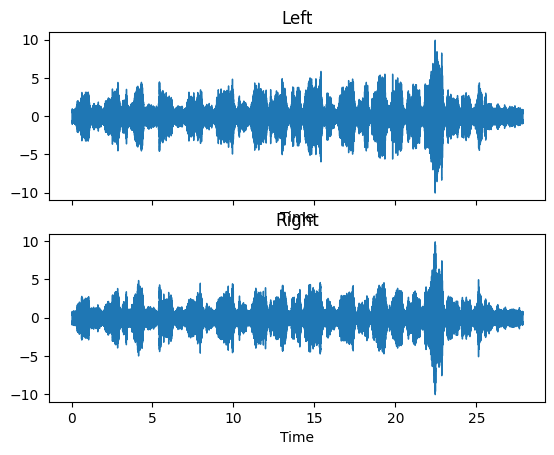

In [28]:
fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.waveshow( audio[0].channel(0), sr=audio[0].sampling_frequency, ax=ax[0])
librosa.display.waveshow( audio[0].channel(1), sr=audio[0].sampling_frequency, ax=ax[1])
ax[0].set(title='Left')
ax[1].set(title='Right')
ax[1].label_outer()

display.display( display.Audio( [audio[0].channel(0),audio[0].channel(1)], rate=audio[0].sampling_frequency ) )


## Affichage de deux voies superposées 

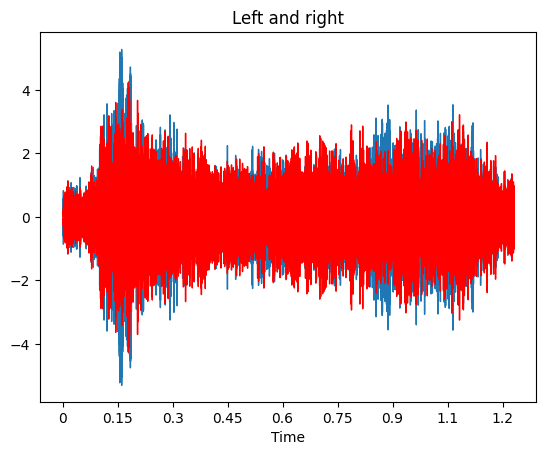

In [30]:
fig, ax = plt.subplots(nrows=1, sharex=True)
#ax.set(xlim=[0.15, 0.16])
librosa.display.waveshow( audio[1].channel(0), sr=audio[0].sampling_frequency, ax=ax, label='channel 0')
librosa.display.waveshow( audio[1].channel(1), sr=audio[0].sampling_frequency, ax=ax, label='channel 1', color='r')
ax.set(title='Left and right')
ax.label_outer()

display.display( display.Audio( [audio[1].channel(0),audio[1].channel(1)], rate=audio[1].sampling_frequency ) )

## Visualiser un spectrogramme
Visualisez le spectrogramme en échelle linéaire et en échelle logarithmique en fréquence:

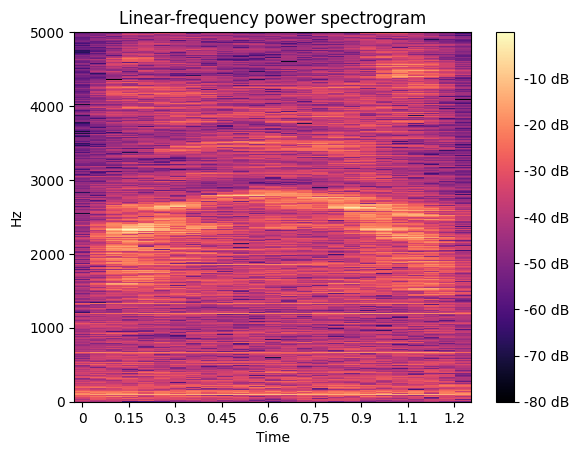

In [43]:
y = audio[1].channel(0)
sr = audio[1].sampling_frequency
fig, ax = plt.subplots( nrows=1, ncols=1, sharex=True )
D = librosa.amplitude_to_db( np.abs( librosa.stft( y ) ), ref=np.max )
img = librosa.display.specshow(D, y_axis='linear', x_axis='time', sr=sr, ax=ax)
ax.set(title='Linear-frequency power spectrogram')
ax.label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")

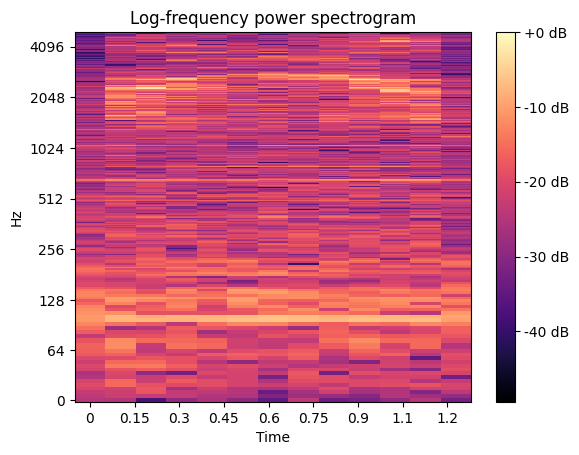

In [42]:
y = audio[1].channel(0)
sr = audio[1].sampling_frequency
hop_length = 1024
fig, ax = plt.subplots( nrows=1, ncols=1, sharex=True )
D = librosa.amplitude_to_db( np.abs( librosa.stft( y, hop_length=hop_length ) ), ref=np.max )
librosa.display.specshow(D, y_axis='log', sr=sr, hop_length=hop_length, x_axis='time', ax=ax)
ax.set(title='Log-frequency power spectrogram')
ax.label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")

In [39]:
session.close()

2023-03-01 16:49:52,161 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-03-01 16:49:52,282 [INFO]:  .Logout successful.


## Visualier un spectrogramme de MEL

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

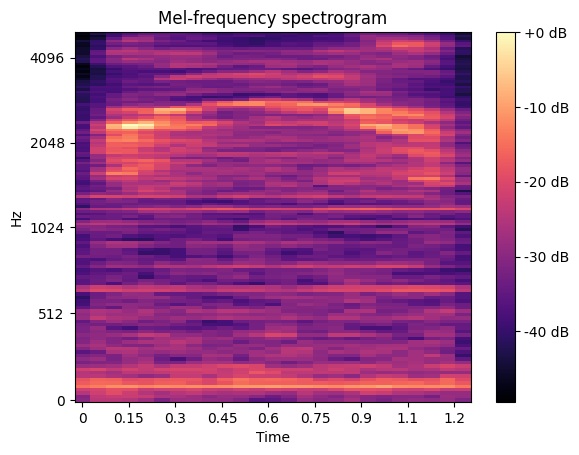

In [41]:
y = audio[1].channel(0)
sr = audio[1].sampling_frequency
s = librosa.feature.melspectrogram(y=y, sr=sr)
s_dB = librosa.power_to_db( s, ref=np.max )
fig, ax = plt.subplots()
img = librosa.display.specshow(s_dB, x_axis='time', y_axis='mel', sr=sr, fmax=sr/2, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')